# EDA — Concrete Compressive Strength

Carga y verificación inicial del dataset UCI *Concrete Compressive Strength* (1030 registros, 8 variables de entrada + resistencia a compresión como variable objetivo). Se revisa estructura, estadística descriptiva, valores nulos y duplicados exactos, como insumo para las decisiones de limpieza del EDA.

In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/Concrete_Data.csv', sep=';')
df.columns = [
    'Cement', 'BlastFurnaceSlag', 'FlyAsh', 'Water',
    'Superplasticizer', 'CoarseAggregate', 'FineAggregate',
    'Age', 'Strength'
]
df.shape

(1030, 9)

**Tipos y completitud.** `info()` confirma el número de filas y columnas, el tipo de dato de cada variable, y la completitud (conteo de no nulos) a nivel de columna.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Cement            1030 non-null   float64
 1   BlastFurnaceSlag  1030 non-null   float64
 2   FlyAsh            1030 non-null   float64
 3   Water             1030 non-null   float64
 4   Superplasticizer  1030 non-null   float64
 5   CoarseAggregate   1030 non-null   float64
 6   FineAggregate     1030 non-null   float64
 7   Age               1030 non-null   int64  
 8   Strength          1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


**Estadística descriptiva.** `describe()` resume media, desviación estándar, mínimo, máximo y cuartiles de cada variable — punto de partida para juzgar rangos plausibles y detectar posibles valores atípicos.

In [3]:
df.describe()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


**Valores nulos.** Conteo explícito de nulos por columna, paso previo obligatorio a cualquier decisión de limpieza.

In [4]:
df.isnull().sum()

Cement              0
BlastFurnaceSlag    0
FlyAsh              0
Water               0
Superplasticizer    0
CoarseAggregate     0
FineAggregate       0
Age                 0
Strength            0
dtype: int64

No hay valores nulos en ninguna de las nueve columnas: las 1030 filas están completas. Esto descarta cualquier estrategia de imputación en esta etapa; la limpieza puede concentrarse en duplicados y en la revisión de valores atípicos.

**Duplicados exactos.** Conteo de filas idénticas en las nueve columnas (incluyendo Age y Strength), con el detalle de los grupos duplicados — insumo para decidir si se eliminan antes del modelado.

In [5]:
print('Filas totalmente duplicadas:', df.duplicated().sum())
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(25)

Filas totalmente duplicadas: 25


,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,Strength
801,252.0,0.0,0.0,185.0,0.0,1111.0,784.0,28,19.69
809,252.0,0.0,0.0,185.0,0.0,1111.0,784.0,28,19.69
83,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
86,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
88,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
91,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
106,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,55.90
109,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,55.90
111,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,55.90
129,362.6,189.0,0.0,164.9,11.6,944.7,755.8,28,71.30


Se encontraron 25 filas totalmente duplicadas (idénticas en las nueve columnas, incluyendo Age y Strength). El detalle muestra grupos de 2 a 4 copias exactas de la misma mezcla y el mismo resultado de ensayo — no hay razón experimental para que un mismo diseño de mezcla, a la misma edad, con el mismo resultado de resistencia, aparezca varias veces como observación independiente. Se interpreta como registro repetido, no como mezclas distintas que coinciden por azar.

In [6]:
n_antes = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
n_despues = df.shape[0]
print(f'Filas antes: {n_antes}')
print(f'Filas después: {n_despues}')
print(f'Filas eliminadas: {n_antes - n_despues}')

Filas antes: 1030
Filas después: 1005
Filas eliminadas: 25


**Decisión: se eliminan los duplicados exactos.** El dataset pasa de 1030 a 1005 filas (25 eliminadas). De aquí en adelante, `df` referencia la versión sin duplicados; es la que se usa en el resto del EDA y en los pasos posteriores del proyecto.

**Frecuencia de Age.** Tabla de conteo de filas por cada edad de ensayo, ya sobre el dataset sin duplicados — insumo directo para decidir la calibración de las fórmulas empíricas.

In [7]:
df['Age'].value_counts().sort_index()

Age
1        2
3      129
7      122
14      62
28     419
56      86
90      54
91      17
100     52
120      3
180     26
270     13
360      6
365     14
Name: count, dtype: int64

La edad de ensayo se concentra fuertemente en 28 días (419 de 1005 filas, ~42%), el estándar de referencia en control de calidad de concreto; el resto se reparte entre 3, 7, 14, 56, 90, 91, 100, 120, 180, 270, 360 y 365 días, todas edades normadas de ensayo y no valores erráticos. Esta distribución confirma, con el dato real ya limpio de duplicados, la base para dos decisiones ya tomadas por el equipo: (i) el subconjunto de Age=28 (~419 filas) es suficientemente grande para calibrar de forma robusta las fórmulas empíricas clásicas, y (ii) las edades largas (90 días en adelante) no se tratan como outliers a eliminar, sino como ensayos normados válidos de curado prolongado.

**Análisis de correlación.** Correlación de Pearson de cada variable con Strength, y matriz completa visualizada como mapa de calor, sobre el dataset ya sin duplicados.

Strength            1.000000
Cement              0.488283
Superplasticizer    0.344209
Age                 0.337367
BlastFurnaceSlag    0.103374
FlyAsh             -0.080648
CoarseAggregate    -0.144717
FineAggregate      -0.186448
Water              -0.269624
Name: Strength, dtype: float64


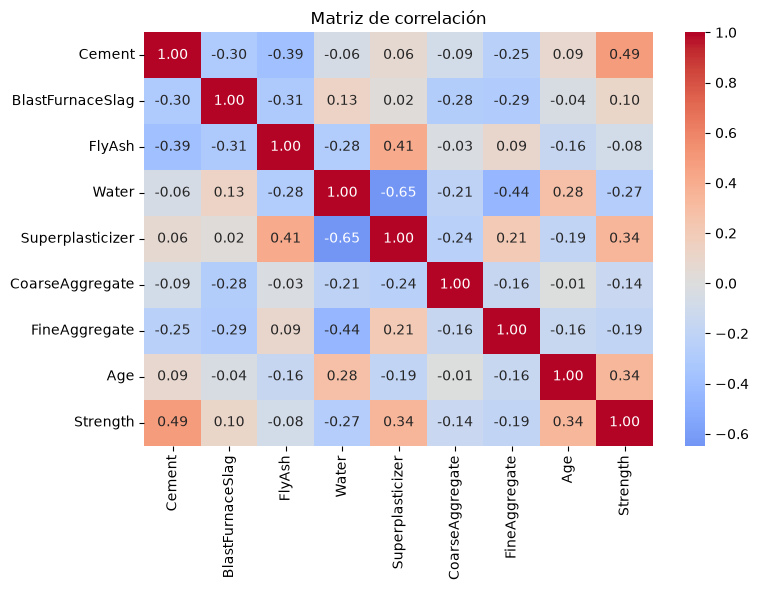

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr(numeric_only=True)
print(corr['Strength'].sort_values(ascending=False))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

Cement (+0.49) es la variable con mayor correlación positiva con Strength, seguida de Superplasticizer (+0.34) y Age (+0.34); Water muestra la correlación negativa más fuerte (-0.27), consistente con la relación agua/cemento clásica de la literatura (a mayor agua para un mismo cemento, menor resistencia). BlastFurnaceSlag, FlyAsh, CoarseAggregate y FineAggregate tienen correlaciones lineales débiles con Strength, lo que no implica que sean irrelevantes: la resistencia depende de interacciones entre variables (p. ej. relación agua/cementante) que un coeficiente de Pearson univariado no captura, y que modelos no lineales como Random Forest o XGBoost sí pueden aprovechar.

**Valores atípicos (outliers).** Conteo de outliers por columna con el criterio estándar de rango intercuartílico (IQR): un valor se marca atípico si cae fuera de `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]`. Se calcula sobre las nueve variables, incluyendo Age, para tener el panorama completo antes de decidir qué hacer con cada una.

In [9]:
def resumen_outliers_iqr(data):
    filas = []
    for col in data.columns:
        q1, q3 = data[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((data[col] < lo) | (data[col] > hi)).sum()
        filas.append({'columna': col, 'n_outliers': n_out, 'limite_inf': lo, 'limite_sup': hi})
    return pd.DataFrame(filas).set_index('columna')

resumen_outliers_iqr(df)

,n_outliers,limite_inf,limite_sup
columna,,,
Cement,0,-46.750,586.450
BlastFurnaceSlag,2,-213.750,356.250
FlyAsh,0,-177.450,295.750
Water,15,127.150,232.350
Superplasticizer,10,-15.000,25.000
CoarseAggregate,0,783.500,1179.500
FineAggregate,5,577.450,969.050
Age,59,-66.500,129.500
Strength,8,-8.505,76.895


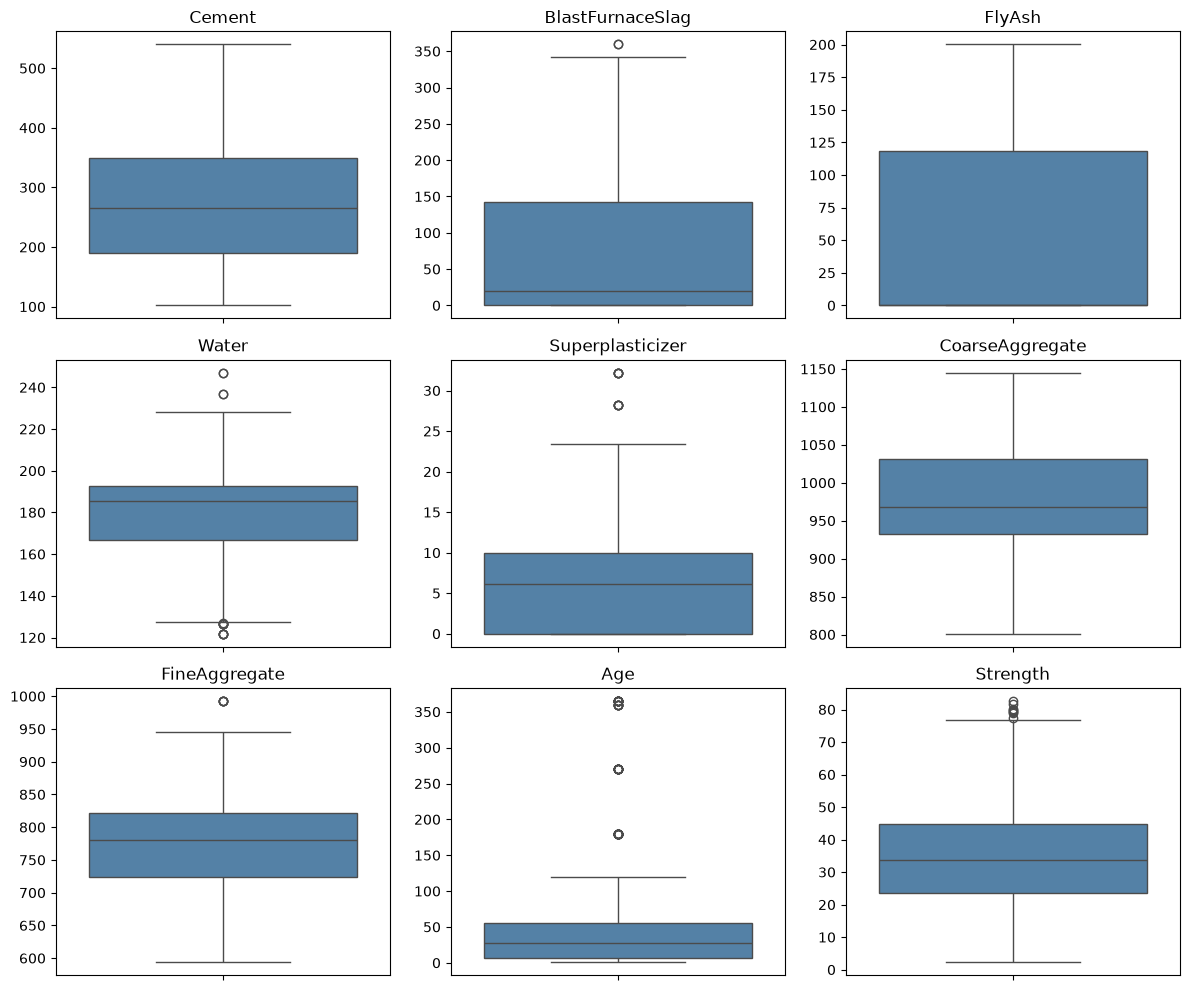

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for ax, col in zip(axes.flat, df.columns):
    sns.boxplot(y=df[col], ax=ax, color='steelblue')
    ax.set_title(col)
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

El criterio IQR marca outliers en Water (15), Superplasticizer (10), FineAggregate (5), BlastFurnaceSlag (2) y Strength (8); Cement, FlyAsh y CoarseAggregate no tienen ninguno. Age concentra 59, que corresponden a las edades de curado largas (90 días en adelante) ya identificadas en la tabla de frecuencia — son ensayos normados, no mediciones erróneas, y su tratamiento ya quedó decidido antes: no se eliminan.

Para las demás variables, los valores marcados están dentro de rangos físicamente plausibles para dosificación de concreto (por ejemplo, Water no baja de 121.8 ni supera 247 kg/m³; Superplasticizer llega como máximo a 32.2 kg/m³): son mezclas reales con proporciones distintas, no errores de captura. Además, Random Forest y XGBoost —los modelos elegidos para T2/T3— son robustos a valores extremos en las variables predictoras, a diferencia de un modelo lineal.

**Decisión: no se elimina ninguna fila por outliers.** Se documentan los conteos por transparencia, pero se mantiene el dataset completo (1005 filas antes y 1005 después de esta revisión) para el análisis y el modelado.

In [11]:
n_antes_outliers = df.shape[0]
# decisión: no se filtra por outliers (ver justificación arriba)
n_despues_outliers = df.shape[0]
print(f'Filas antes: {n_antes_outliers}')
print(f'Filas después: {n_despues_outliers}')
print(f'Filas eliminadas: {n_antes_outliers - n_despues_outliers}')

Filas antes: 1005
Filas después: 1005
Filas eliminadas: 0


**Distribución de cada variable.** Histogramas de las nueve variables sobre el dataset limpio (sin duplicados), para juzgar simetría, concentración de valores y presencia de picos en cero.

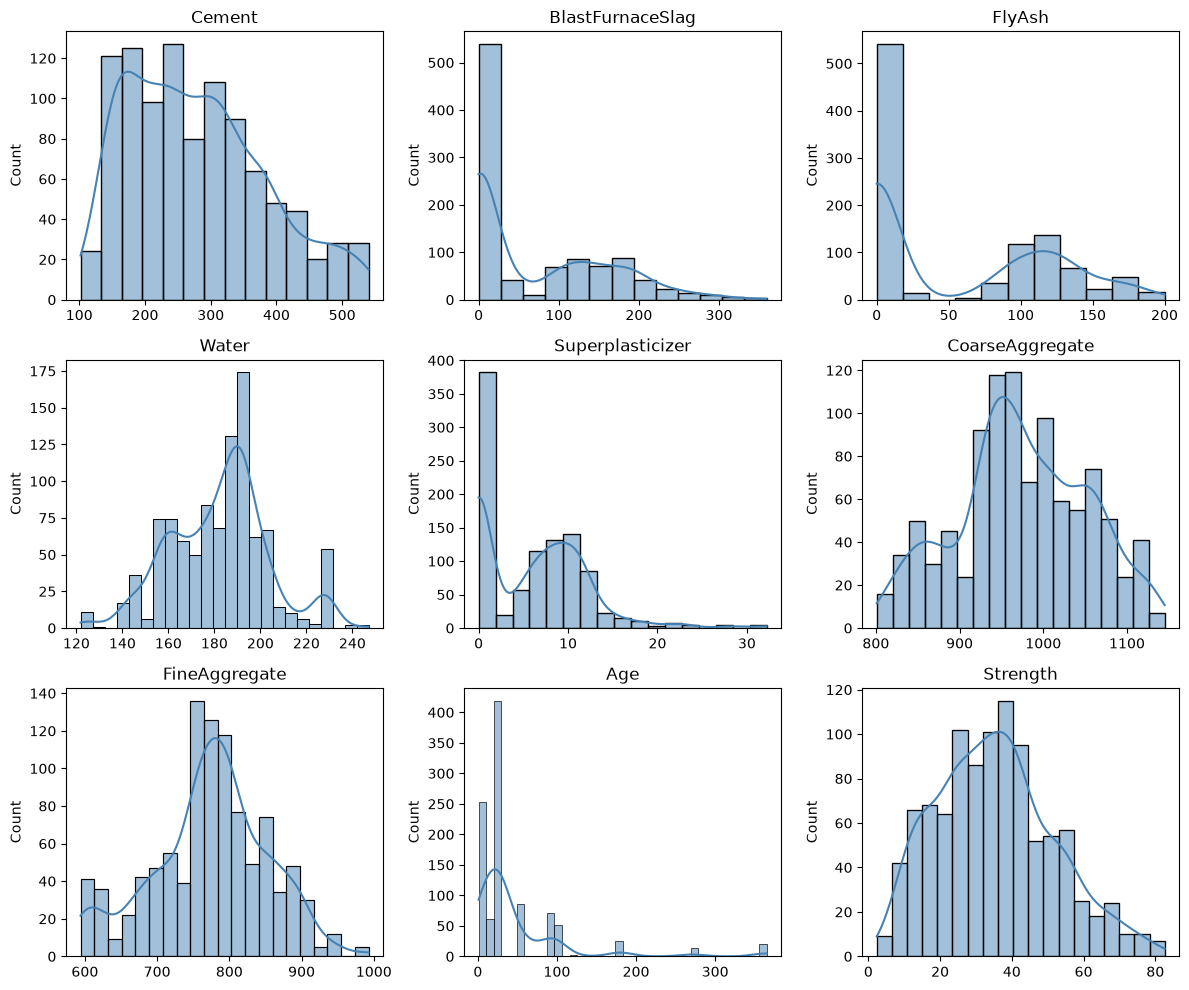

Age                 3.253974
Superplasticizer    0.980604
BlastFurnaceSlag    0.855225
Cement              0.564959
FlyAsh              0.497231
Strength            0.395696
Water               0.034433
CoarseAggregate    -0.065256
FineAggregate      -0.252353
dtype: float64

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for ax, col in zip(axes.flat, df.columns):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

df.skew(numeric_only=True).sort_values(ascending=False)

Age es, por lejos, la variable más asimétrica (asimetría 3.25) — coherente con la concentración en 28 días ya vista en la tabla de frecuencia y con la cola larga hacia 180–365 días. BlastFurnaceSlag (46.8%, 470 filas), FlyAsh (53.8%, 541 filas) y Superplasticizer (37.6%, 378 filas) muestran un pico marcado en cero: no son datos faltantes ni error, sino que reflejan mezclas de concreto donde ese componente simplemente no se usó — muchas dosificaciones no incluyen escoria, ceniza volante o superplastificante. Water es la variable más simétrica (asimetría ≈ 0.03), cercana a una distribución normal. Esta asimetría generalizada refuerza, junto con los outliers ya revisados, la preferencia por modelos de árboles (Random Forest, XGBoost) frente a modelos lineales, que sí exigen supuestos de normalidad o requerirían transformar variables.

**Relación de cada predictor con Strength.** Diagramas de dispersión de las ocho variables de entrada contra la resistencia a compresión, para inspeccionar visualmente la forma de la relación (lineal, no lineal, dispersa) más allá del coeficiente de correlación univariado.

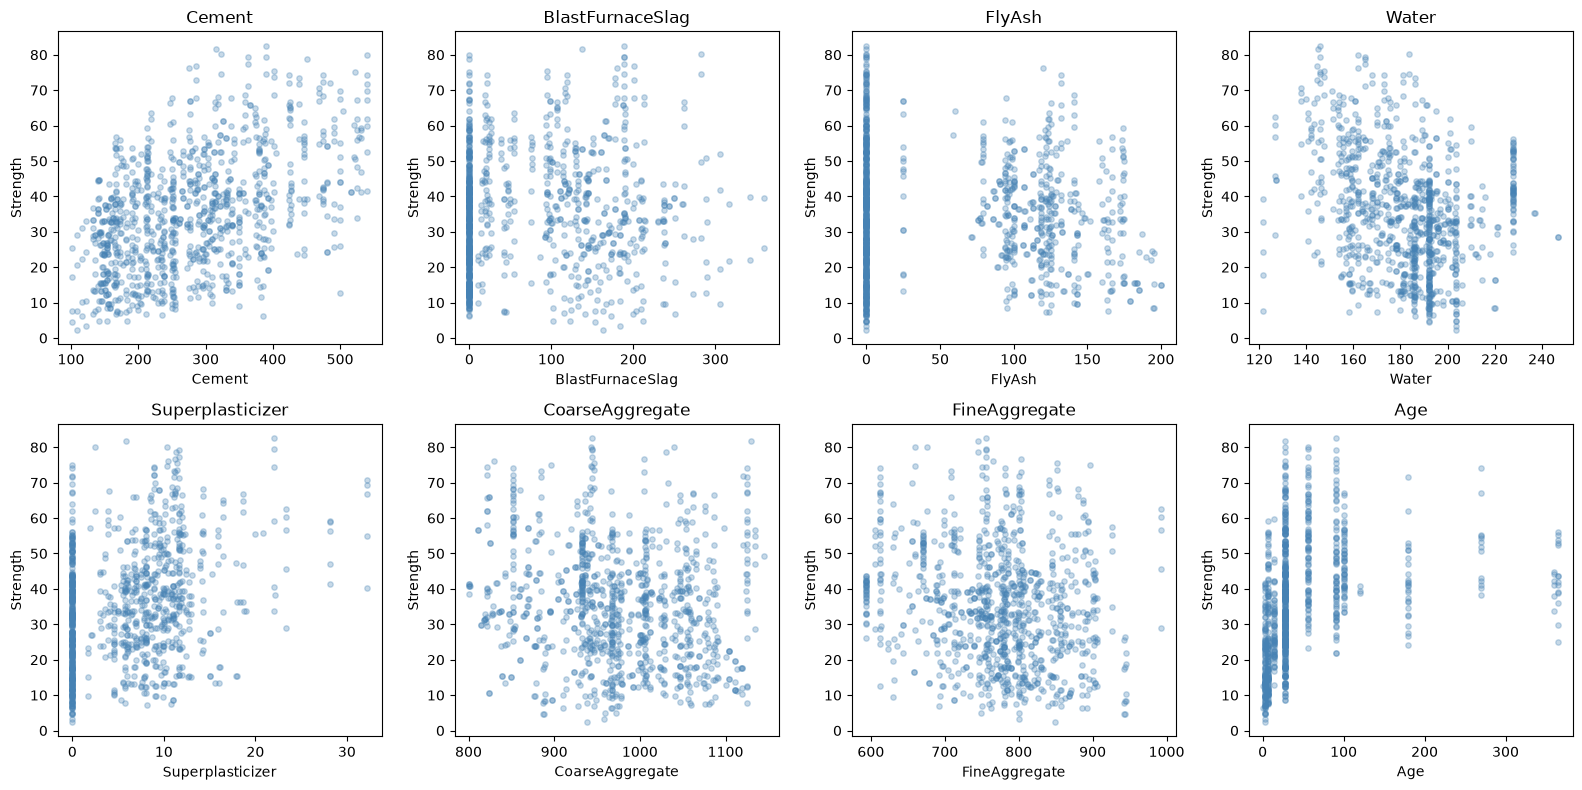

In [13]:
predictores = [c for c in df.columns if c != 'Strength']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, predictores):
    ax.scatter(df[col], df['Strength'], alpha=0.3, s=15, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Strength')
plt.tight_layout()
plt.show()

Cement y Superplasticizer muestran una tendencia ascendente con Strength, pero con dispersión considerable — consistente con sus correlaciones moderadas (+0.49 y +0.34) y con el hecho de que la resistencia depende de la combinación de variables, no de una sola. Age destaca por una forma claramente no lineal: la resistencia sube con rapidez en los primeros días y luego se aplana en edades largas, un comportamiento esperable del curado del concreto (la mayor parte de la ganancia de resistencia ocurre en las primeras semanas) que una correlación lineal (+0.34) subestima. Water se dispersa en una nube amplia con tendencia descendente leve, y BlastFurnaceSlag, FlyAsh, CoarseAggregate y FineAggregate no muestran un patrón visual claro de forma aislada — refuerza la conclusión de la sección de correlación: estas variables aportan mejor en combinación que de forma individual, y justifica usar un modelo capaz de capturar no linealidades e interacciones (Random Forest, XGBoost) en vez de una regresión lineal simple.

**Variables derivadas: w/c y w/b.** La literatura clásica de resistencia del concreto (Ley de Abrams) no trabaja con las 8 variables por separado, sino con la relación agua/cementante como predictor único. Se calculan aquí, sobre el dataset ya limpio de duplicados, dos variantes de esa relación como columnas temporales (no se agregan de forma permanente a `df`): `w/c` (Water/Cement) y `w/b` (Water/(Cement+BlastFurnaceSlag+FlyAsh), donde "b" de *binder* incluye los tres materiales cementantes). Se compara su correlación individual con Strength contra la de las 8 variables originales.</cell_type>
</invoke>


In [14]:
df_temp = df.copy()
df_temp['wc'] = df_temp['Water'] / df_temp['Cement']
df_temp['wb'] = df_temp['Water'] / (df_temp['Cement'] + df_temp['BlastFurnaceSlag'] + df_temp['FlyAsh'])

corr_originales = df.corr(numeric_only=True)['Strength'].drop('Strength')
corr_derivadas = df_temp[['wc', 'wb', 'Strength']].corr()['Strength'].drop('Strength')

print('Correlación de las 8 variables originales con Strength (orden por magnitud):')
print(corr_originales.reindex(corr_originales.abs().sort_values(ascending=False).index))
print()
print('Correlación de las variables derivadas (w/c, w/b) con Strength:')
print(corr_derivadas.reindex(corr_derivadas.abs().sort_values(ascending=False).index))
print()
comparacion = pd.concat([corr_originales, corr_derivadas]).rename('correlación con Strength')
comparacion = comparacion.reindex(comparacion.abs().sort_values(ascending=False).index)
print('Comparación conjunta, ordenada por magnitud:')
print(comparacion)

Correlación de las 8 variables originales con Strength (orden por magnitud):
Cement              0.488283
Superplasticizer    0.344209
Age                 0.337367
Water              -0.269624
FineAggregate      -0.186448
CoarseAggregate    -0.144717
BlastFurnaceSlag    0.103374
FlyAsh             -0.080648
Name: Strength, dtype: float64

Correlación de las variables derivadas (w/c, w/b) con Strength:
wb   -0.610843
wc   -0.489401
Name: Strength, dtype: float64

Comparación conjunta, ordenada por magnitud:
wb                 -0.610843
wc                 -0.489401
Cement              0.488283
Superplasticizer    0.344209
Age                 0.337367
Water              -0.269624
FineAggregate      -0.186448
CoarseAggregate    -0.144717
BlastFurnaceSlag    0.103374
FlyAsh             -0.080648
Name: correlación con Strength, dtype: float64


Ambas variables derivadas superan en magnitud a las 8 variables originales: w/b tiene la correlación más fuerte de todo el análisis (-0.61), por delante de w/c (-0.49) y de Cement (+0.49), la mejor de las variables originales. El signo negativo es el esperado por la Ley de Abrams: a mayor relación agua/cementante, menor resistencia. Que w/b supere a w/c confirma, con datos propios del dataset, que incluir escoria y ceniza volante en el denominador (además del cemento) captura mejor la resistencia que la relación agua/cemento clásica — motivo por el cual se calibrarán ambas variantes por separado para Abrams y Power Formula, en vez de asumir de antemano cuál rinde mejor.

**Nota — uso previsto de w/c y w/b.** Estas dos columnas son temporales: se calculan aquí solo para inspección y no se agregan de forma permanente a `df`. Su único uso en el proyecto es calibrar las fórmulas empíricas normativas (Abrams y Power Formula) como baseline cuantitativo, mediante el método Parameter Trend Regression, en `00_baseline_empirico.ipynb`. Random Forest y XGBoost, en cambio, se entrenan con las 8 variables originales sin combinar: un modelo de árboles puede aprender por sí solo la interacción equivalente a agua/cementante (y otras combinaciones no lineales) a partir de las variables por separado, mientras que una fórmula de una sola variable, como Abrams o Power, necesita que esa combinación se le entregue ya calculada de antemano.
</invoke>
